In [5]:
import numpy as np
from numpy.random import default_rng
from sklearn.metrics import f1_score
from scikit_quri.qnn.classifier import QNNClassifier
from scikit_quri.circuit.pre_defined import create_qcnn_ansatz
from quri_parts.core.estimator.gradient import (
    create_numerical_gradient_estimator,
)
from quri_parts.qulacs.estimator import (
    create_qulacs_vector_concurrent_estimator,
    create_qulacs_vector_concurrent_parametric_estimator,
)
from quri_parts.algo.optimizer import LBFGS

In [6]:
def generate_data(bits: int, random_seed: int = 0):
    """Generate training and testing data."""
    rng = default_rng(random_seed)
    n_rounds = 20
    excitations = []
    labels = []
    for n in range(n_rounds):
        for bit in range(bits):
            r = rng.uniform(-np.pi, np.pi)
            excitations.append(r)
            labels.append(1 if (-np.pi / 2) <= r <= (np.pi / 2) else 0)

    split_ind = int(len(excitations) * 0.7)
    train_excitations = excitations[:split_ind]
    test_excitations = excitations[split_ind:]

    train_labels = labels[:split_ind]
    test_labels = labels[split_ind:]

    return train_excitations, np.array(train_labels), test_excitations, np.array(test_labels)

In [7]:
nqubit = 8  # 量子ビット数。現在8固定
random_seed = 0  # 乱数のシード値
circuit = create_qcnn_ansatz(nqubit, random_seed)

In [8]:
from scikit_quri.backend import SimEstimator
num_class = 2  # 分類数（ここでは2つに分類）
optimizer = LBFGS()
estimator = SimEstimator()
gradient_estimator = create_numerical_gradient_estimator(
    create_qulacs_vector_concurrent_parametric_estimator(), delta=1e-3
)

qcl = QNNClassifier(circuit, num_class, estimator, gradient_estimator, optimizer=optimizer)

In [9]:
maxiter = 20  # ループの最大。これが多いほど、正確になるが、時間がかかる。6分
x_train, y_train, x_test, y_test = generate_data(nqubit)
qcl.fit(np.array(x_train), np.array(y_train), maxiter)
y_pred = qcl.predict(np.array(x_test)).argmax(axis=1)
print("f1_score: ", f1_score(y_test, y_pred, average="weighted"))

 iter:16/20 cost:optimizer_state.cost=0.5638079787063845
f1_score:  0.9584057971014494


1.5018188912132147


<Axes: >

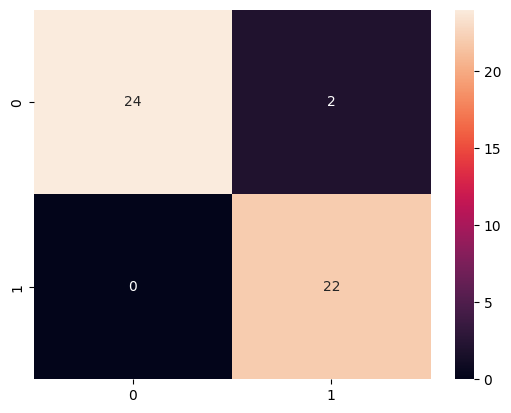

In [12]:
from sklearn.metrics import log_loss, confusion_matrix
import seaborn as sns
log = log_loss(y_test, y_pred)
print(log)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)